### Lecture 14

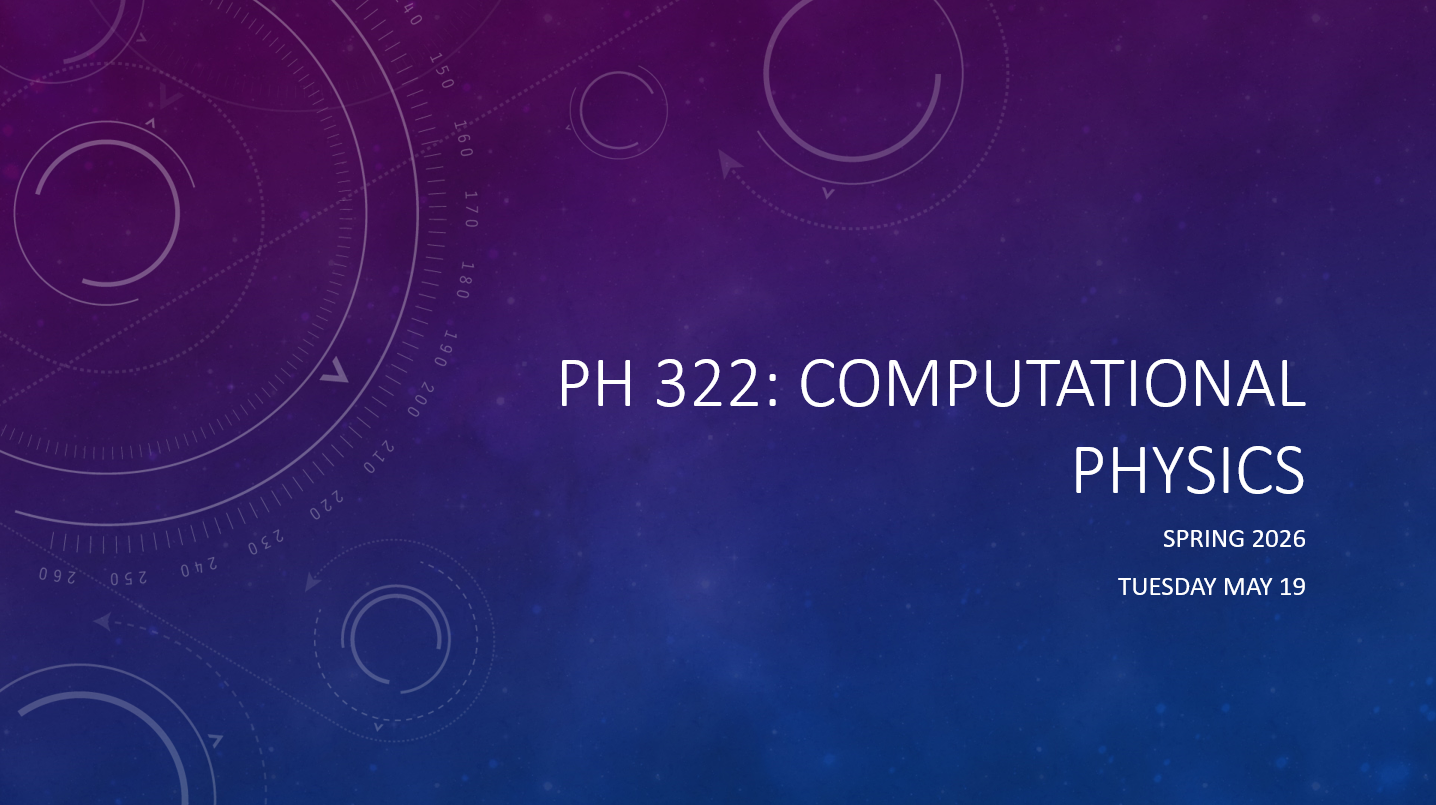

In [2]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture14.png"))

**Announcements**
* HW7 due tonight.


**Last Class**
* RK4 - Conservation of energy
* Boundary value problems
* Shooting method with binary search
 

**Today's Class**
* Partial differential equations
  * Laplace equation
  * Poisson equation
  * Jacobi method
  * Gauss-Seidel method
  * Overrelaxation
  * Diffusion equation
  * Forward-Time Centered-Space (FTCS) method
  * Numerical stability




## Chapter 9 Partial differential equations

We next learn numerical methods to solve partial differential equations (PDEs). A number of famous physics equations are PDEs including the wave equation and Schroedinger's equation. Unlike ordinary differential equations, PDEs have more than one independent variable, so they require different techniques to solve them (although we will use Euler's method in one technique). 

Consider the electromagnetic wave equation in one dimension. Here the equation includes not only the derivative of the wave function in time, but the derivative of the function in space: 

$$
\frac{\partial^2 E}{\partial x^2}  =\frac{1}{c^2}\frac{\partial^2 E}{\partial t^2}
$$

The equation contains both time $t$ and position $x$ as independent variables, so the solution $E(x,t)$ is a 2D function. 

Just like ordinary differential equations, PDEs require boundary conditions to solve. Since PDEs often include position variables as independent variables, PDEs often have boundary conditions along a spatial dimension, in addition to initial conditions.

We will look at solving partial differential equations with spatial boundary conditions first, then move on to initial conditions. 

### Laplace equation - Electrostatics with no charges

The canonical PDE boundary value problem is to calculate the electric potential inside a box with conducting walls. The lower three walls are in electrical contact and grounded so are all at zero potential. The upper wall however is not in contact with the lower walls and is kept at a potential $V$. This is a *Dirichlet condition*, when the function is specified along its boundaries.  

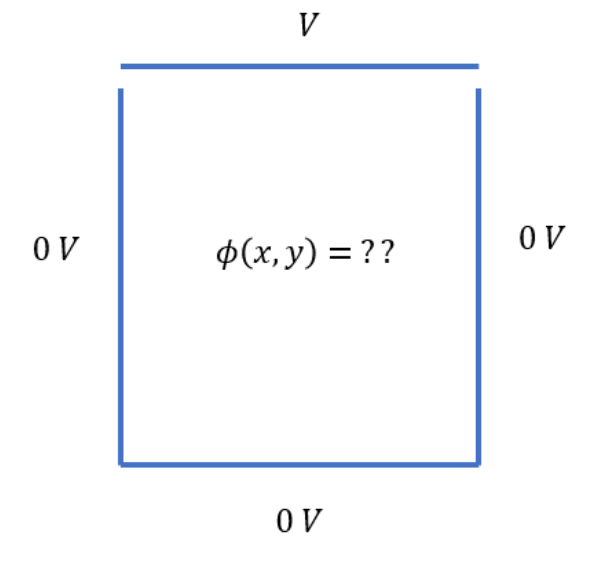

In this case, the potential along the boundaries of the box constrain what the potential function inside the box will be.  We will use Gauss's Law to derive the governing partial differential equation for the potential $\phi$. 

We start with the integral form of Gauss's Law for the electric field, which states:

$$
\oint_{S} \mathbf{E} \cdot d\mathbf{A} = \frac{Q_{enc}}{\epsilon_0}
$$

Here $\oint_{S} \mathbf{E} \cdot d\mathbf{A}$ is the surface integral of the electric field $\mathbf{E}$ over a closed surface $S$ and $Q_{\text{enc}}$ is the total charge enclosed by that surface. 


According to the divergence theorem, the surface integral of a vector field over a closed surface is equal to the volume integral of the divergence of that field over the volume enclosed by the surface:

$$
\oint_S \mathbf{E} \cdot d\mathbf{A} =\int_V(\nabla \cdot \mathbf{E}) dV
$$

Applying this to Gauss's Law we get:

$$
\int_V(\nabla \cdot \mathbf{E}) dV = \frac{Q_{enc}}{\epsilon_0}
$$

The total charge $Q_{enc}$ within the volume $V$ can be expressed as a volume integral of the charge density $\rho$:

$$
Q_{enc} = \int_V \rho dV
$$

Substituting this expression into the equation, we get:

$$
\int_V (\nabla \cdot \mathbf{E}) \, dV = \frac{1}{\epsilon_0} \int_V \rho dV
$$

Since this equation holds for any arbitrary volume $V$, we can equate the integrands:

$$
\boxed{\nabla \cdot \mathbf{E} = \frac{\rho}{\epsilon_0}}
$$

This is the differential form of Gauss's Law. It states that the divergence of the electric field at any point in space is equal to the charge density at that point divided by the permittivity of free space.

Since there are no electric charges inside the box, this becomes:

$$\nabla \cdot \mathbf{E} = 0
$$

And since the electric field and potential are related by

$$
\mathbf{E} = -\nabla\phi,
$$

we can combine the two equations to get

$$-\nabla \cdot \nabla\phi = 0,
$$

or

$$\nabla \cdot \nabla\phi = 0,
$$

which in two dimensions is



$$\nabla \cdot \nabla\phi  = \left(\frac{\partial}{\partial x}, \frac{\partial}{\partial y}\right) \cdot \left(\frac{\partial \phi}{\partial x}, \frac{\partial \phi}{\partial y}\right) = \frac{\partial^2 \phi}{\partial x^2} +  \frac{\partial^2 \phi}{\partial y^2} = 0,
$$

which is Laplace's equation, a second-order partial differential equation:

$$
\boxed{\frac{\partial^2 \phi}{\partial x^2} +  \frac{\partial^2 \phi}{\partial y^2} = 0}
$$

### Finite difference methods to solve PDEs

The first numerical method we'll use to solve partial differential equations is a *finite difference* method.  There are a number of different finite difference methods, but in all, the basic approach is to discretize the solution space by dividing the solution space into a grid of finite points. The solution at each point is found by numerically approximating the partial derivaties at each grid poiont as a finite difference between neighboring grid points. This turns the partial differential equation into a system of linear equations which we can solve using a number of techniques, including the *relaxtion* and *Forward-time Centered-space* methods.

Finite difference methods can used to solve a number of classes of PDEs including the Laplace equation, Poisson equation, wave equation, and the diffusion equation. 

We apply the finite difference method here to solve the Laplace equation above.

First we break up our function space into a grid of equal sized cells with cell width $a$:

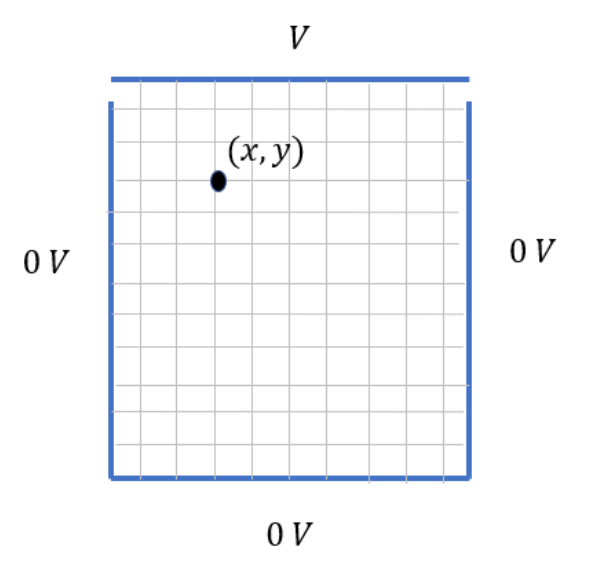


The spacing of the grid cells doesn't necessarily have to be uniform but for our purposes we will make them even (though they don't look that way above).

We calculate the partial derivative at each grid cell point $(x,y)$ using the central difference approximation we learned in Chapter 6.

Let's write out the partial second derivatives using central differences (see section 5.10.5 for a review of second derivatives) in each dimension at grid point $(x,y)$. The spacing between grid points in both dimensions is $a$. To estimate the partial derivative with respect to $x$, we find the difference in the function $\phi$ between neighboring grid cells along the $x$ dimension, while hold the $y$ variable constant, and vice versa for the partial derivative with respect to $y$:

$$
\frac{\partial^2\phi}{\partial x^2} = \frac{\phi (x+a,y) + \phi(x-a,y) - 2\phi(x,y)}{a^2},
$$

$$
\frac{\partial^2\phi}{\partial y^2} = \frac{\phi (x, y+a) + \phi(x, y-a) - 2\phi(x,y)}{a^2}.
$$

With these definitions, we can write Laplace's equation as:

$$
\frac{\partial^2\phi}{\partial x^2} + \frac{\partial^2\phi}{\partial y^2}  = \frac{\phi (x+a,y) + \phi(x-a,y) - 2\phi(x,y) + \phi (x, y+a) + \phi(x, y-a) - 2\phi(x,y)}{a^2}
$$

$$
= \frac{\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a) - 4\phi(x,y)}{a^2} = 0
$$

If we multiply both sides by $a^2$, Laplace's equation becomes:

$$
\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a) - 4\phi(x,y)= 0
$$

So at each grid point we will have an equation like this. 

Notice the LHS of the equation is just the sum of the potential at every grid point around point (x,y) minus 4 times the potential at the grid point (x,y) itself:

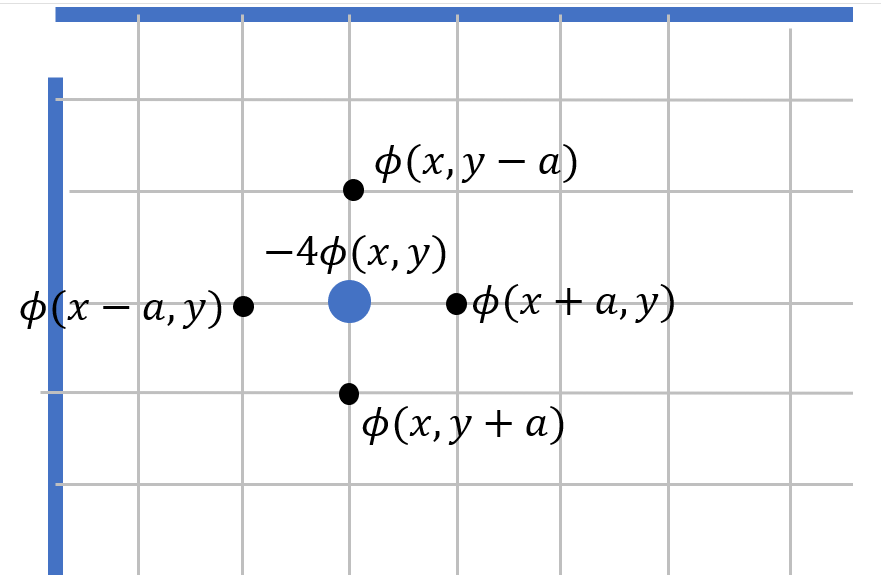

So if we have $N\times N$ grid points, we will have $N\times N$ equations, with $N\times N$ unknowns. The unknowns of course are the values of the potential at each $N\times N$ grid point. 

Notice also, that each of the unknowns is a linear term, there are no higher powers of $\phi$. So we have reduced the second-order partial differential equation into a system of linear equations to solve. 

### Jacobi method  - Relaxation method revisited

We can use any of our methods to solve the $N\times N$ system of linear equations including Gaussian elimination or LU decomposition, but we can also solve using the *relaxation method*, which we learned earlier this term, and is easier to code. 

Remember the relaxation method requires us to make an initial guess of the solution for all the variables in our system of equations. We then calculate the value of the function at each grid point using those guesses. We determine if the solution has converged to our target error, and if not, we use the current estimate to calculate the next one.

Remember also when we use the relaxation method,  we have to get our equations into the form:

$
x = f(x,y,..)
$

$
y = g(x,y,..)
$

So too here, so we write the equations as:

$$
\phi(x_0,y_0) = \frac{1}{4}\left(\phi (x_0+a,y_0) + \phi(x_0-a,y_0) + \phi (x_0, y_0+a) + \phi(x_0, y_0-a) \right).
$$

$$
\phi(x_0,y_1) = \frac{1}{4}\left(\phi (x_0+a,y_1) + \phi(x_0-a,y_1) + \phi (x_0, y_1+a) + \phi(x_0, y_1-a) \right).
$$

$$
\phi(x_0,y_2) = \frac{1}{4}\left(\phi (x_0+a,y_2) + \phi(x_0-a,y_2) + \phi (x_0, y_2+a) + \phi(x_0, y_2-a) \right).
$$

$$
\ldots,
$$

or in general,
$$
\phi(x_i,y_j) = \frac{1}{4}\left(\phi (x_i+a,y_j) + \phi(x_i-a,y_j) + \phi (x_i, y_j+a) + \phi(x_i, y_j-a) \right),
$$

We have one of these equations at each grid point $(x_i,y_j)$.

Since in this problem the boundary conditions are known, we only solve for $\phi(x_i,y_i)$ at the interior grid points. So if our set of grid points is of size $M\times N$, in Python we initially fix the values of $\phi(x,y)$ along the boundary as:

(first row)
$
\phi(0,:)=V \qquad \text{top wall} 
$

(last row)
$
\phi(M-1,:) = 0 \qquad \text{bottom wall} 
$

(first column)
$
\phi(:,0) = 0 \qquad \text{left wall} 
$

(last column)
$
\phi(:, N-1) = 0 \qquad \text{right wall} 
$

We then have $(M-2)\times(N-2)$ interior grid points, and $(M-2)\times(N-2)$ equations, and  $(M-2)\times(N-2)$ unknowns.

We make an initial guess of these unknowns and perform the relaxation method until the solution converges. 

To test for convergence we require that all $(M-2)\times(N-2)$ solutions converge, by simply comparing the current iteration with the previous one. This method to solve systems of linear equations is called the **Jacobi method** and benefits from being simple to implement. 



### Poisson equation

Next let's put some electric charge inside the box. In this case Gauss's Law is:


$$\vec{\nabla} \cdot \vec{E} = \rho/\epsilon_0
$$

where $\rho$ is the charge density. In two dimensions $\rho=\rho(x,y)$. $\epsilon_0$ is the permittivity of free space assuming we are in empty space.

And since:

$$
\vec{E} = -\vec{\nabla}\phi,
$$

$$\vec{\nabla} \cdot \vec{\nabla}\phi = -\rho/\epsilon_0
$$

and:

$$\nabla^2 \phi= -\rho/\epsilon_0
$$

which is Poisson's equation. It tells us for a specified charge distribution $\rho$ we can calculate the potential. 

We can solve this in the same manner as we did Laplace's equation, with finite differences and relaxation.

The equivalent equations to solve are now:

$$
\frac{\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a) - 4\phi(x,y)}{a^2} = -\frac{\rho(x,y)}{\epsilon_0}
$$

or solving for $\phi(x,y)$:
$$
\phi(x,y) = \frac{1}{4}(\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a) + \frac{a^2 \rho(x,y)}{4\ \epsilon_0}
$$

This is very similar to what we just solved, just with the added charge density term, which we need to create based on the problem set-up. Here the problem states the box contains two $20\times20$ cm regions that contain positive and negative charge density of 1 C/m$^2$.

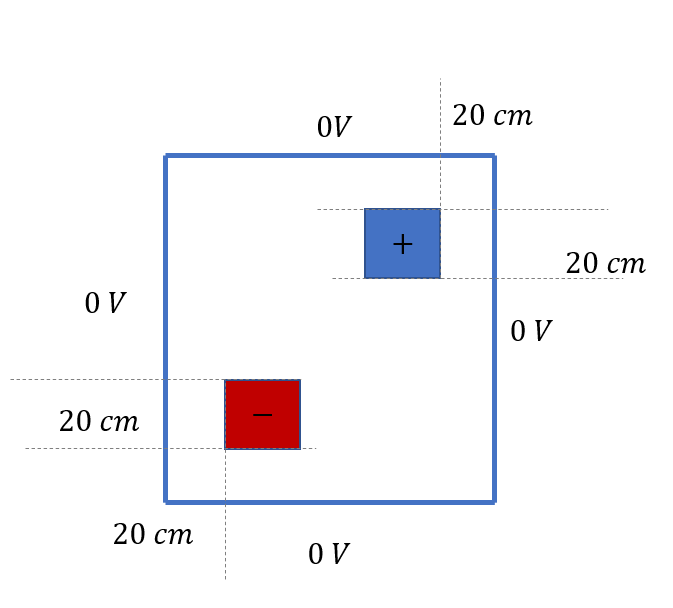

Assume the potential is zero along all four walls.

The code for this problem is very similar to the code above. The main difference is we will also need to create an array to hold the charge density $\rho$, since that is part of the differential equation. The array should be the same size as the array that holds the potential. We then add this charge density term to our function for $\phi$.

We create the charge density array simply by specifying the appropriate indices of the subarrays where there is charge.  

I recommend plotting your charge density array to verify it looks reasonable. 

 ### The Gauss-Seidel method.

The main disadvantage of the Jacobi method we've used above is it's slow. If I decrease the target error to $10^{-6}$, which is still a relatively modest target, it takes over 10,000 iterations to converge. 

The next two methods we'll go over, the **Gauss-Seidel** and  **overrelaxation** methods, produce similarily accurate results but faster, in the case of the overrelaxation method much faster, and there is very little work to actually modify our Jacobi code to implement them. So they are both kind of a no-brainer.

The Gauss-Seidel method is so simple, you may have invented it yourself without knowing it, or are already using it.

In the traditional relaxation method, such as the Jacobi method we used above, we used the array of the previous solution in order to calculate each element in the new solution. That is to say, if the array $\mathbf{x}$ stored all the elements from the previous solution, the Jacobi method says to calculate the new solutions from all of these previous solutions, as this figure shows:

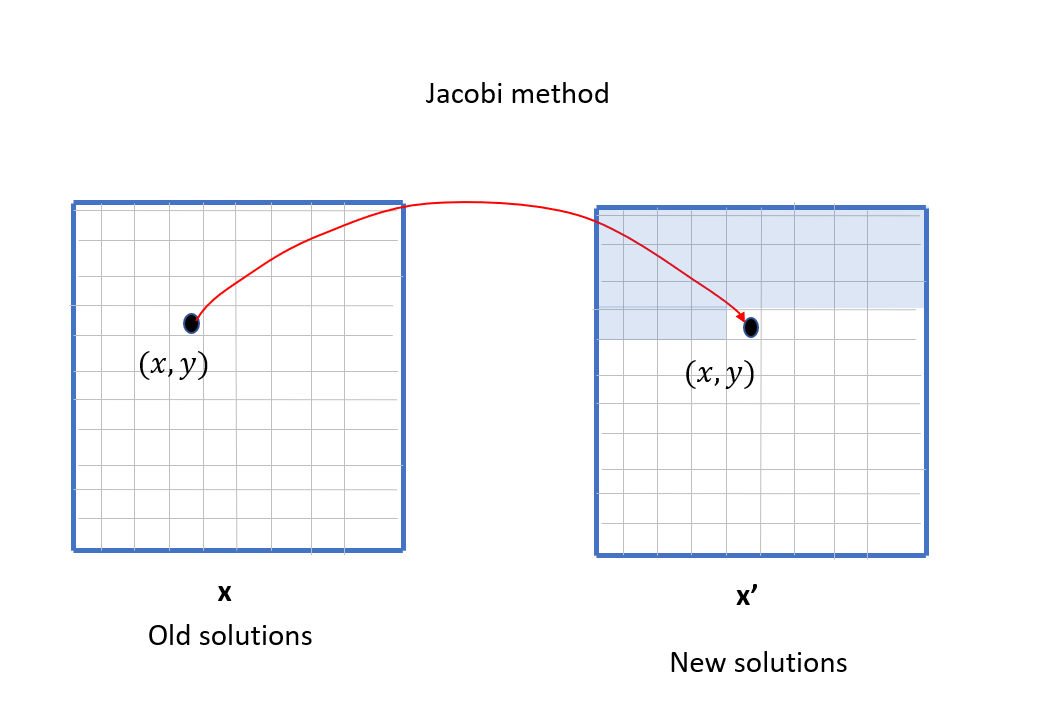

That's fine, but we can do better. 

In the figure, the shaded cells are cells where we have already calculated a new solution. Notice that the calculation of $\phi$ in the current grid cell (x,y) would use some of the new solutions, if they were made available to the calculation. And in most cases the new solutions are improvements over the old solutions. So if the current calculation could use them, the solution will likely converge faster.

So that is the "trick" if you want to call it that, of the Gauss-Seidel method. We simply update our array that stores the solutions with the new ones as soon as we calculate them. That will allow later calculations of the potential in later grid cells to benefit from them. 

I illustrate the Gauss-Seidel method like this:


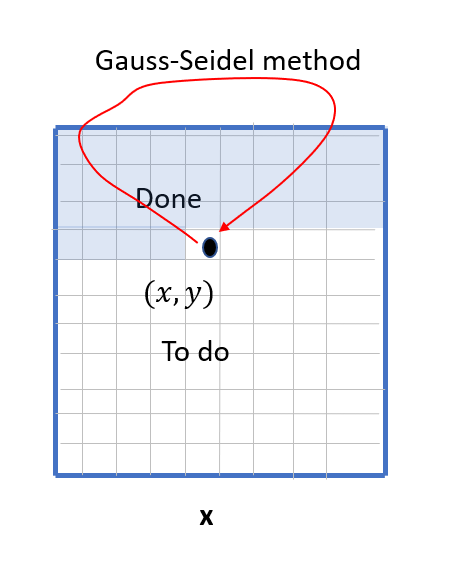

The illustration shows just one array. We don't need an intermediate array to store our new solutions, we just update the current element in the one array we use to store the potential. I indicate this with the arrow that passes the solution back to the same element in the array. 

The code to do this in Python is simple, in fact you may have already done this when you solved the relaxation problem from Chapter 6.

Let's say that we use the array *solution* to store the current solution of the relaxation method. We calculate the new solution by passing this array to our function *phi()* that calcuates the new solution.  We simply pass the result from *phi* back into solution like this:

```python
# inside a nested for loop
solution[j,i] = phi(i,j,solution)
```

Python evaluates assignment statments like this from right to left. So it will first evaluate *phi()* using the "done" solutions to calculate the new solution at (x,y) (or index j,i in my sample code), and pass this back into the array solution. 



One other thing to note about the revised code. Since I need to compare the new solution with the previous solution, I make a copy of solution[j,i] and save it in the variable *store*. This is just a scalar variable, not an array. 

I find it now takes 235 iterations to converge vs. 243 with the Jacobi method, for a target error of 1e-3 V, and 1451 vs 1897 iterations for an error of 1e-4 V, so there is an improvement, but slight.  

### Overrelaxation method

The Gauss-Seidel trick saves a little bit of time, but not much. 

The overrelaxation method however can save a significant of computation time, and is easy to code to boot.

The basic idea of the overrelaxation method is illustrated below:

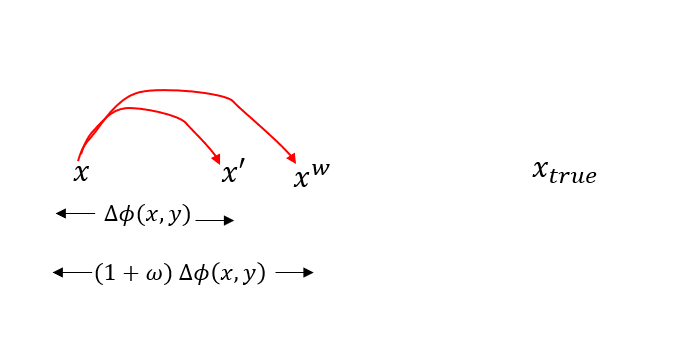

In the relaxation method, each solution gets us a little bit close to the true solution. If $x$ is the  current guess of the solution, then in the next iteration the guess is improved to $x'$. We then move our solution from $x$ to $x'$.

Overrelaxation "asks", if the hop from $x$ to $x'$ moves us closer to $x_{true}$, why not hop just a little bit more?

So let's go back to the Laplace equation problem. We can write the new solution $\phi'(x,y)$ as:

$$
\phi'(x,y) = \phi(x,y) + \Delta \phi(x,y)
$$

where $\Delta \phi(x,y)$ is just the difference, or the hop, between the two. 

Overrelaxation "says", let's hop a little bit more, by an amount $(1+\omega)\Delta \phi(x,y)$, where $\omega > 0$.  Doing so the next step will be at:

$$
\phi_w(x,y) = \phi(x,y) + (1+\omega)\Delta \phi(x,y)
$$


And since $\Delta \phi(x,y) = \phi'(x,y) -\phi(x,y)$, 

substituting in above, we get


$$
\phi_w(x,y) = \phi(x,y) + (1+\omega)(\phi'(x,y) -\phi(x,y))
$$

$$
= (1+\omega)\phi'(x,y)  -\omega \phi(x,y)
$$

For $\phi'(x,y)$ we use the equation we derived above for Laplace's equation:

$$
\phi(x,y)' = \frac{1}{4}\left(\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a) \right)
$$

Substituting in above: 

$$
\boxed{\phi_w(x,y)= \frac{1+\omega}{4}[\,\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a)]\, -\omega \phi(x,y))}
$$


The boxed equation is the **overrelaxation** method applied to the Laplace equation. It is a minor adjustment to our normal relaxation method, and in many cases can reduce the amount of iterations needed for our solution to converge. 

The only remaining question, is what value to choose for $\omega$? There is no value that will be best all the time, so some trial and error is needed. But to ensure the solution remains stable, it's best to choose a value less than one. So in many cases, 0.9 is a good choice. 

Solution converged in 91 iterations


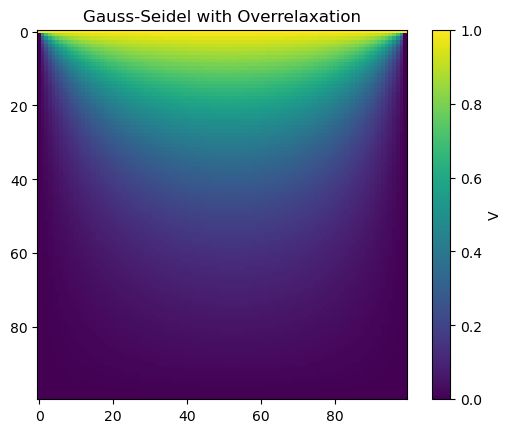

In [8]:
"""
@author: cbute

Program: ex9.2_gauss_seidel_with_overrelaxation
Purpose: Practice using Gauss-Seidel method with overrelaxation 
Does it work?: Yes
Other information: 
    
    # code adapted from example 9.1
    # takes about 30 seconds, at target=1e-6
"""
import numpy as np
import matplotlib.pyplot as plt
import sys

def phi(i,j,V):
    omega  = 0.9
    return (1.0+omega)*(V[j, i+1]+V[j,i-1]+V[j+1,i]+V[j-1,i])/4 - omega*V[j,i]


# define boundary potentials 
Vtop = 1.0 #volt
Vbottom = 0.0 #volt
Vleft = 0.0 #volt
Vright = 0.0 #volt

# define grid spacing
a = 1e-2 # m

# grid size, assume square
N = 100

# create array to hold potential, and initialize to 0
solution = np.zeros([N,N], float)

# place boundary values in phi array
# careful values do not overwrite one another.
solution[N-1,:] = Vbottom
solution[:,0] = Vleft
solution[:,N-1] = Vright
solution[0,:] = Vtop

# set error target
epsilon = 1e-3 # volt

# create logical convergence variable
converge = False

it = 0 # iteration counter
while converge == False:
    it += 1
    converge = True
    # calculate new solutions just on the interior points
    for j in range(1,N-1):
        for i in range(1,N-1):
            store = solution[j,i]
            solution[j,i] = phi(i,j,solution) # use the old solutions to calculate new solutions
            if abs(solution[j,i]-store) > epsilon:
                converge = False

print ("Solution converged in {} iterations".format(it))                
plt.imshow(solution)
plt.title("Gauss-Seidel with Overrelaxation")
plt.colorbar(label="V")
plt.show()

Remarkable. For a target error of $10^{-3}$ what took 235 iterations without overrelaxation now takes just 91 iterations. The savings is even more impressive for smaller target errors. What took 1451 iterations to achieve an error of $10^{-4}$ before using the Gauss-Seidel method, now takes only 198 iterations.  Overrelaxation provides great value for our coding effort. 

##  Initial-valued PDE problems

In these last partial differential equations, e.g. Laplace's and Poisson's problems, the function we solved for, $\phi(x,y)$, was a function of two spatial dimensions. In these cases the boundary values were specified along the spatial boundaries of the function, *i.e.*, we specified the potential along the walls of the box.  

But consider this PDE, the heat or diffusion equation given by:

$$
\frac{\partial \phi}{\partial t} = D\frac{\partial ^2 \phi}{\partial x^2}
$$

where $\phi$ represents some quantity that can be diffused, like heat or the concentration of a gas, $D$ is the diffusion coefficient, $t$ is time, and $x$ is a spatial variable. This equation can be used to describe the flow of heat or fluids due to random diffusive processes. 

The details of the equation don't matter for now, but note that the solution to the equation $\phi$ is a function of both time and space.  Therefore the solution can be visualized as a set of values bounded by both time and space:

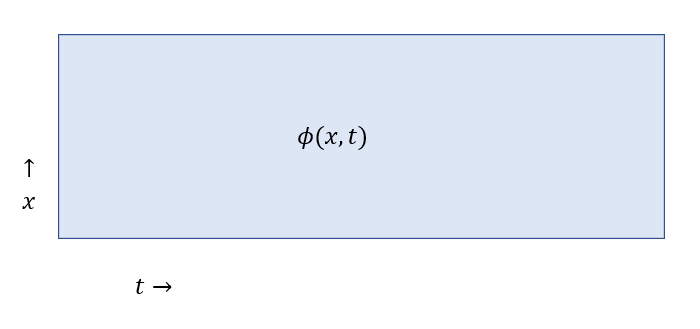

In order to solve this problem as we did before with either the Jacobi or Gauss-Seidel method with relaxation we need the value of $\phi$ along the four boundaries. But since one of the boundaries is time, this would require us knowing the function $\phi$ at the end of the time interval. But most often we only know it at the beginning of the time interval, that is the initial condition. 

Because of this limitation, the methods we've used before to solve PDEs won't work, since we can't calculate partial derivatives at the interior grid points without knowing the function along all of its boundaries.  

### The Forward-Time Centered-Space (FTCS) method

One method to solve initial-valued PDEs is using the **forward-time centered-space** method. The trick here is to turn the initial-valued PDE problem into a system of ordinary differential equations which we can solve with one of our ODE methods, such as the Euler or Runge-Kutta methods. 

To do this we first divide the spatial dimension into a number of grid points as shown below. We specify the function $\phi$ at each grid point as shown. 


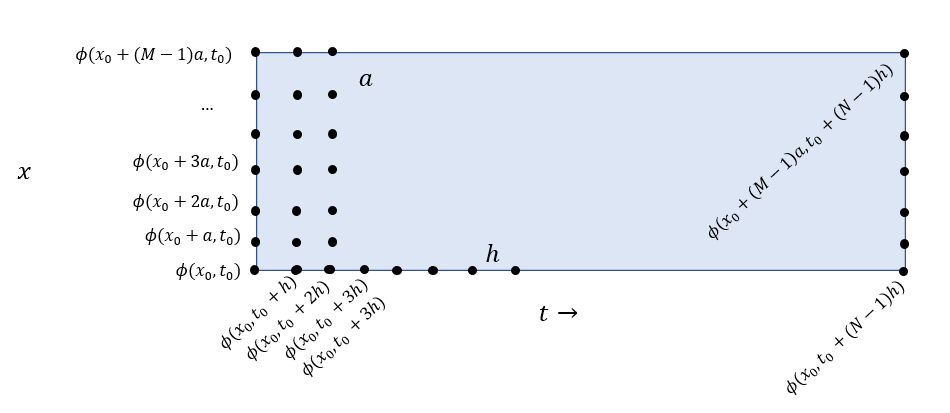

The value of $\phi$ at each grid point can be considered a separate variable. For example, we can think of $\phi(x_0+a,t)$ as variable $\phi_{x_0+a}(t)$ which is only a function of $t$, and $\phi(x_0+2a,t)$ as variable $\phi_{x_0+2a}(t)$. 

Doing so, turns the partial differential equation into a number of ordinary differential equations with time $t$ as the independent variable. Therefore if we divide the spatial dimension into $M$ grid points we have $M$ variables, and $M$ equations to solve. We then solve the ODE for each variable $\phi_m(t)$. 

### Apply the FTCS method to the diffusion equation

Let's now apply the FTCS method to the diffusion equation: 

$$
\frac{\partial \phi}{dt} = D\frac{\partial ^2 \phi}{\partial x^2}.
$$



First, we write the partial second derivatives in the RHS in the equation like we did before using central differences:

$$
\frac{\partial^2\phi}{\partial x^2} = \frac{\phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t)}{a^2}
$$

so the diffusion equation becomes

$$
\frac{d \phi}{dt} =  \frac{D}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right),
$$

where $a$ is the gap spacing between the grid points along the spatial dimenision. It is determined by the physical length of the spatial interval and the number of grid points $M$. 

Here $\phi$ means the values of $\phi$ along only one row, not a function of  $x$. So we now have an ordinary differential equation, not partial. This means we can use one of our ODE methods to solve it. 

At each grid point in the spatial dimension we have one of these equations. So let's just say we have 3 interior grid points at $x_1, x_2, x_3$, then we have these three equations to solve:

$$
\frac{d \phi_1}{dt} =  \frac{D}{a^2}\left( \phi_2 (t) + \phi_0(t) - 2\phi_1(t) \right)
$$

$$
\frac{d \phi_2}{dt} =  \frac{D}{a^2}\left( \phi_3 (t) + \phi_1(t) - 2\phi_2(t) \right)
$$

$$
\frac{d \phi_3}{dt} =  \frac{D}{a^2}\left( \phi_4 (t) + \phi_2(t) - 2\phi_3(t) \right)
$$

where:

$$
\phi_0(t)= \phi(x_0,t)
$$

$$
\phi_1(t) = \phi(x_0 + a,t)
$$

$$
\phi_2(t) = \phi(x_0+2a,t)
$$

$$
\phi_3(t) = \phi(x_0+3a,t)
$$

$$
\phi_4(t) = \phi(x_0+4a,t).
$$






We can write this system of differential equations in vector form like we have done before:

$$
\frac{d \mathbf{r}}{dt} = \mathbf{f}({\mathbf{r}, t}),
$$

where $\mathbf{r} = (\phi_1, \phi_2, \phi_3)$, and $\mathbf{f}({\mathbf{r}, t}) = (f_1,f_2,f_3)$, where



$$
f_1 = \frac{D}{a^2}\left( \phi_2 (t) + \phi_0(t) - 2\phi_1(t) \right)
$$

$$
f_2 = \frac{D}{a^2}\left( \phi_3 (t) + \phi_1(t) - 2\phi_2(t) \right)
$$

$$
f_3 =  \frac{D}{a^2}\left( \phi_4 (t) + \phi_2(t) - 2\phi_3(t) \right)
$$


We have already solved a system of ODEs before. What method should we use here? 

Although normally we would want to use the 4th-order RK for most ODEs, here we can get away with using Euler's method, because the approximation error we incurred when replacing the partial derivatives with central differences is much larger than the approximation error on the RK4 method, so we might as well use the *slightly-easier-to-code* Euler's method (though if you have RK code lying around, it's really not that difficult to use, even though we don't expect to get any gain in accuracy)

Using Euler's method, we cast each ordinary differential equation into this form:

$$
\frac{d\phi}{dt} = f(\phi,t)
$$

and the solution at time $t+h$ is given by:

$$
\phi(t+h) = \phi(t)+h\frac{d\phi(t)}{dt} 
$$

$$
= \phi(t)+hf(\phi,t)
$$

and in this case:

$$
f(\phi,t) = \frac{D}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right)
$$

so 

$$
\phi(x,t+h) = \phi(x,t) + h\frac{D}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right)
$$



So if we know the initial value of $\phi(t)$ at all grid points $x_i$, we then can step forward and calculate $\phi(x,t)$ over the entire time interval.

### Practice Exercise - Solve the diffusion equation using the FTCS method

Let's practice coding the FTCS for the following diffusion problem. 

The flat base of a container made of a 1 cm thick stainless steel is initially at a uniform temperature of $20^\circ$C everywhere. The container is placed in a bath of cold water at $0^\circ$C and filled with hot water at $50^\circ$C. 

Calculate the temperature profile of the steel as a function of distance $x$ from the hot side to the cold side, and as a function of time. For simplicity treat the base of the container as being arbitrarily wide, so that its temperature profile is the same everywhere, and assume that neither the hot nor the cold water changes temperature.

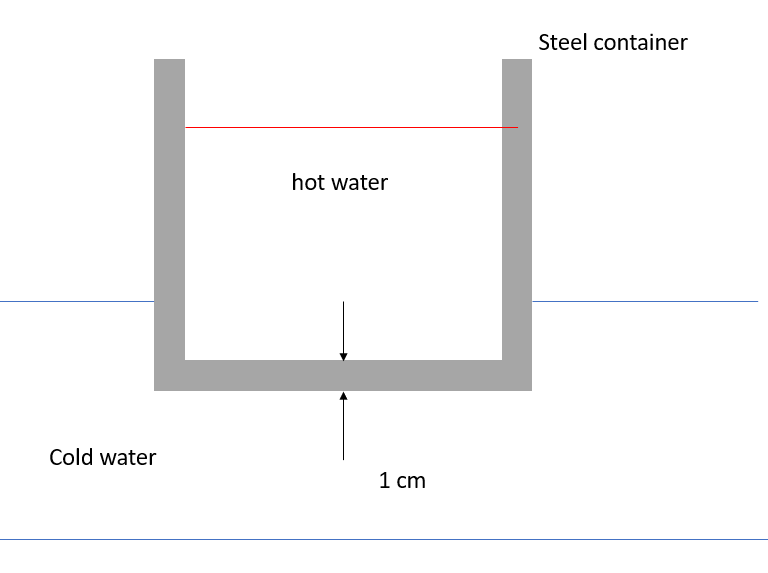

Thermal conduction is governed by the heat equation:

$$
\frac{\partial \phi}{dt} = D\frac{\partial ^2 \phi}{\partial x^2}
$$

where $D$ is the diffusion coefficient for steel, $4.25\times 10^{-6}$ m$^2$s$^{-1}$. 

We have already derived the system of equations we need to solve above:

$$
\frac{d \phi}{dt} =  \frac{hD}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right)
$$


We can divide the $x$-dimension up into $M=100$ grid points, so we have a system of 98 equations to solve, since we solve only on the interior grid points. 

The initial condition specifies the temperature profile across the steel at time $0$:

$$
\phi(0,t=0) = 50^\circ C \qquad \text{top} 
$$

$$
\phi(M-1,t=0) = 0^\circ C \qquad \text{bottom} 
$$

$$
\phi(1:M-2,t=0) = 20^\circ C \qquad \text{everywhere else}
$$

The spatial boundary condition requires the temperatures at the top and bottom surfaces to be maintained constant over the time interval:


$$
\phi(0,t) = 50^\circ C \qquad \text{top} 
$$

$$
\phi(M-1,t) = 0^\circ C \qquad \text{bottom}
$$

or using Python array slicing notation:



$$
\phi(0,:) = 50^\circ C   
$$

$$
\phi(M-1,:) = 0^\circ C   
$$


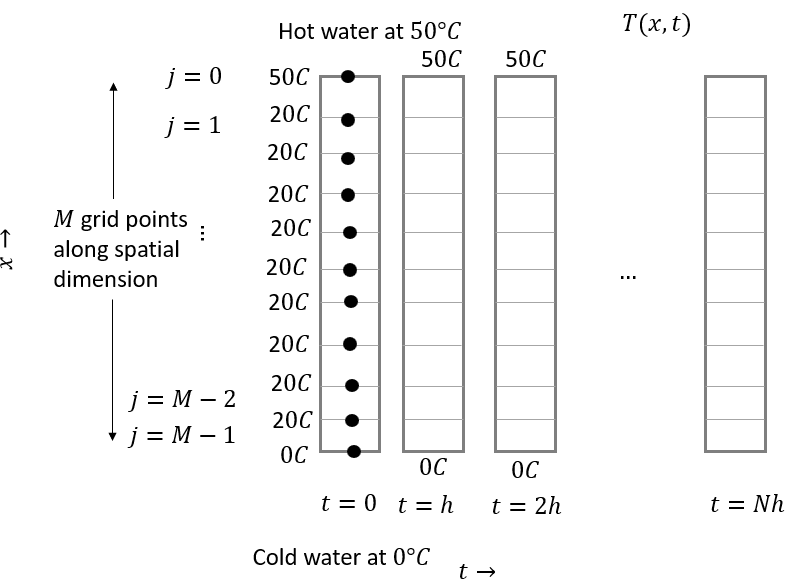

We solve the equations using Euler's method:

$$
\phi(x,t+h) = \phi(x,t) + \frac{hD}{a^2}\left( \phi (x+a,t) + \phi(x-a,t) - 2\phi(x,t) \right)
$$

Let's think about the pseudo-code.

1. Define any physical constants including the diffusion coeffient and thickness of container.
2. Define the size of the solution grid, that is $\phi(x,t)$. You will need to define the number of grid spacings along the $x$ and $t$-dimensions. For the purposes of this problem, choose $M=100$ space points, and $T=10000$ time points.
3. Create an $M\times N$ array to store the temperatures at each grid point.
4. Specify the initial and boundary conditions.
5. Define the time interval over which to calculate the solution, use 10 seconds. 
6. Calculate the size of each time step.
7. Calculate the distance between each grid point in the $x$-dimension. This is $a$.
8. For plotting purposes, create 1D arrays to hold the x-positions and times at each grid point.
9. Using a ```for```-loop, step through the time interval
    * For each time step, update the values of each $\phi_m$ using Euler's method. Rememer to only update the interior points.
10. Plot the temperature profile at the end of the time interval.

Note, convert temperatures to Kelvin. 

The top plot shows the temperature across the steel as a function of both the thickness of the steel, $x$,  and time. The bottom plot shows the temperature profile across the steel at different times. Notice that at t=0, the steel is at its initial temperature of $20^{\circ} C$ everywhere except at the end points. Then as time progresses the heat signatures penetrate into the steel, until at $t=10$ s, there is a constant temperature gradient across the steel. 

### Application of FTCS to the wave equation

We see above the FTCS method works well in solving the diffusion equation. We can calculate the solution out to time $t$ and the solution remains stable.

Let's try applying the FTCS method to the wave equation. Here again is the wave equation in one dimension:

$$
\frac{\partial^2\phi}{\partial t^2} = v^2\frac{\partial^2\phi}{\partial x^2}
$$

where $v$ is the wave velocity.

In order to solve this using the FTCS method, we again divide the spatial dimension, in this case $x$,  into a number of grid points separated by width $a$, and treat the value of the solution $\phi$ along $x$ as separate variables. Doing so, turns the partial derivative into an ordinary derivative.

We write the partial derivative as before using finite differences:

$$
\frac{d^2\phi_x}{d t^2} = \frac{v^2}{a^2}\left[\phi_{x+a}(t)+\phi_{x-a}(t)-2\phi_x(t)\right]
$$


Since this is a second-order differential equation we break it into two first-order equations by defining a new variable $\psi$:

$$
\frac{d\phi_x}{dt} = \psi_x(t)
$$

With this definition we can write the second derivative as:

$$
\frac{d \psi_x}{dt} = \frac{v^2}{a^2}\left[\phi_{x+a}(t)+\phi_{x-a}(t)-2\phi_x(t)\right]
$$

And to solve this using Euler's method, the solutions at each time step are given by:   

$$
\phi_x(t+h) = \phi_x(t) +h\psi_x(t)
$$

$$
\psi_x(t+h) = \psi_x(t) + h\frac{v^2}{a^2}\left[\phi_{x+a}(t) + \phi_{x-a}( t)-2\phi_x(t)\right]
$$

We can calculate the solutions given some boundary conditions of the problem. 

Let's assume this wave equation describes the displacement of a string of length $L=1.0m $, and the velocity of a wave on the string is 100 m/s.  The string is initially stretched to be in the shape of a sine wave, $\sin{2\pi x/L}$, and held at rest. Therefore  $\frac{d \psi}{dt}=0$ initially.

### Practice Exercise - Application of FTCS method to the wave equation.

If you have your FTCS code working for the diffusion equation above, copy it below and revise it for the wave equation. Use $M=100$ grid points in the $x$-dimension, and $N=10000$ grid points in the time dimension. Calculate the solution from $t=0$ milliseconds to $t=20$ milliseconds. Make a plot of the displacments of the wave at a couple of different times in the interval. 

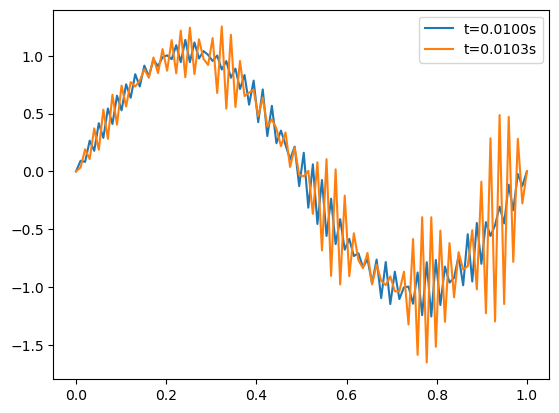

In [2]:
time = t2/2 # specify time to sample function, s
i = np.argmin(abs(tvalues - time))
# plot phi as a function of xt 
plt.plot(xvalues, phi[:,i],label = f"t={time:0.4f}s")

time = t2/1.95 # specify time to sample function, s
i = np.argmin(abs(tvalues - time))
# plot phi as a function of xt 
plt.plot(xvalues, phi[:,i],label = f"t={time:0.4f}s")
plt.legend()
plt.show()


However, now we see the solution is becoming numerically unstable. If we plot the solution even later:

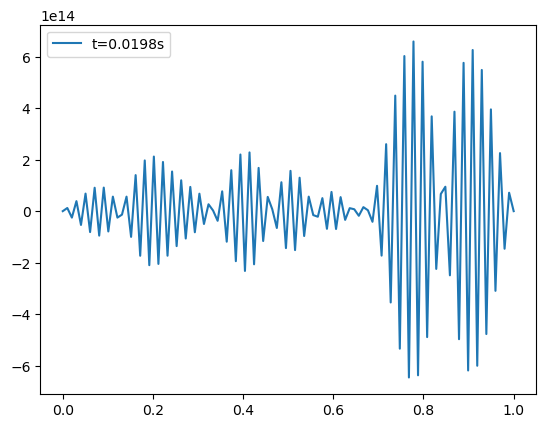

In [3]:
time = t2/1.01 # specify time to sample function, s
i = np.argmin(abs(tvalues - time))
# plot phi as a function of xt 
plt.plot(xvalues, phi[:,i],label = f"t={time:0.4f}s")
plt.legend()
plt.show()

It just continues to get worst. Notice the amplitude is $1e14$. If we continue much longer the solution gets so big it overflows. 

Here we can watch the destruction of the wave play out using a VPython animation. I'll go over some of the details of the animation in a later example. 

In [4]:
# vpython animation of vibrating string.

from vpython import canvas, vector, color, curve, rate, wtext

canvas(width=500, height=300, center=vector(.5,0,0))

wave = curve(retain=M, color=color.red)

tstart = 1e-3
tend = 60e-3
tstep = 1e-5

timestamp = wtext(text=f"t={tvalues[0]:0.4f}s")

for i in range(N):
    timestamp.text=f"t={tvalues[i]:0.4f}s"
    displacement = phi[:,i]   
    rate(50)
    for i in range(M):
        d = vector(xvalues[i],0.5*displacement[i],0)
        wave.append(d)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

What we see here is that the use of the FTCS method to solve the wave equation is numerically unstable, except for very short time periods, and this is a general result when the FTCS method is used to solve the wave equation.